This notebook is to analyze the classification of random paraphrases.

In [1]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tikzplotlib
import sys
from pathlib import Path
notebook_dir = Path().resolve()  
src_path = notebook_dir.parent 
sys.path.append(str(src_path))
from src.configuration import *

In [10]:
#Define here which dataset you want to analyze
dataset='MMLU'

In [11]:
subsets_dataset=subsets[dataset]
models=modifications['random']
DATA_FOLDER=f"../data/{dataset}/paraphrases/random/"

In [12]:
all_results=[]
for subset in subsets_dataset:
    for model in ['chatgpt', 'deepseek']:
        DATA_FILE=DATA_FOLDER+f'{subset}_random_{model}_classified.csv'
        data_df=pd.read_csv(DATA_FILE)
        data_df.loc[:, "subset"] = subset
        data_df.loc[:, "model"] = model
        all_results.append(data_df)
classification_df=pd.concat(all_results)

In [13]:
classification_df.head()

,prepositions,AAE,formal,synonym_substitution,change_voice,subset,model
0,0,0,5,1,0,abstract_algebra,chatgpt
1,0,0,4,2,1,abstract_algebra,chatgpt
2,0,0,2,1,0,abstract_algebra,chatgpt
3,0,0,4,4,0,abstract_algebra,chatgpt
4,0,0,5,5,0,abstract_algebra,chatgpt


In [14]:
# Add 'other' column: 1 if all paraphrase columns == 0, else 0
paraphrase_cols = ['prepositions', 'AAE', 'formal', 'synonym_substitution', 'change_voice']
classification_df['other'] = (classification_df[paraphrase_cols].sum(axis=1) == 0).astype(int)

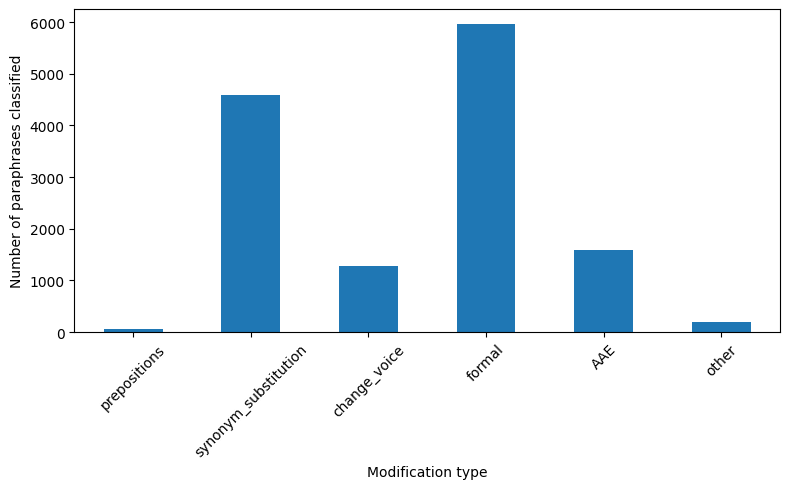

In [15]:
# Barplot of classification of paraphrases
class_df=classification_df.copy()
cols = ["prepositions", "synonym_substitution", "change_voice", "formal", "AAE", "other"]
#for col in cols:
#    class_df[col]=class_df[col]/5
    
# Sum over rows to get counts per category
counts = class_df[cols].sum()#/len(class_df)

# Create barplot
plt.figure(figsize=(8,5))
counts.plot(kind="bar")

#plt.title(f"Classification of random generated paraphrases for {dataset}")
plt.ylabel("Number of paraphrases classified")
plt.xlabel("Modification type")
plt.xticks(rotation=45)
plt.tight_layout()
tikzplotlib.save(f"tex_files/classification_{dataset}.tex")